# Few-Shot Learning con LLM (Qwen2.5-7B via Ollama)

## Motivazione e scelta del modello

In questo notebook esploriamo un approccio radicalmente diverso da quelli precedenti: invece di addestrare un classificatore su features estratte (TF-IDF, embeddings) o di fare fine-tuning, interroghiamo un Large Language Model pre-addestrato fornendogli solo pochi esempi etichettati nel prompt (few-shot learning).

### Perché Qwen2.5-7B e non altri?

Tra le opzioni disponibili via Ollama, abbiamo scelto Qwen2.5-7B-Instruct per le seguenti ragioni:

| Criterio | Qwen2.5-7B | Llama3-8B | Mistral-7B |
|---|---|---|---|
| RAM richiesta (4-bit) | ~5 GB | ~6 GB | ~5 GB |
| Velocità inferenza (CPU) | Alta | Media | Alta |
| Comprensione istruzioni | Eccellente | Buona | Buona |
| Supporto italiano | Ottimo | Medio | Medio |
| Licenza | Apache 2.0 | Llama license | Apache 2.0 |

Qwen2.5-7B è stato scelto perché offre il miglior equilibrio tra qualità di comprensione delle istruzioni e costo computazionale.


### Subset statisticamente significativo (n=400)

Per rendere la valutazione comparabile agli altri approcci senza costi computazionali proibitivi, utilizziamo un subset del test set di 400 campioni stratificati per classe.

Giustificazione statistica:
- Con N=400 e una proporzione attesa ~0.5 (classi bilanciate), il margine di errore sulla stima dell'accuracy è circa del 5%
- Questo garantisce stime affidabili con intervallo di confidenza al 95%.
- Il campionamento è stratificato per mantenere le proporzioni originali delle classi.

## Import e Setup

In [ ]:
import pandas as pd
import numpy as np
import json
import time
import random
import requests
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, classification_report
)

# Seed per riproducibilità
RANDOM_SEED = 42
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

# Configurazione
SUBSET_SIZE   = 400          # campioni per la valutazione
N_SHOTS       = 8            # esempi nel prompt
MODEL_NAME    = "qwen2.5:7b" # modello Ollama
OLLAMA_URL    = "http://localhost:11434/api/generate"
RESULTS_PATH  = "../results/fewshot_results.json"
FIGURES_PATH  = "../figures/"

print("Setup completato.")
print(f"  Modello    : {MODEL_NAME}")
print(f"  N-shot     : {N_SHOTS}")
print(f"  Subset size: {SUBSET_SIZE}")

Setup completato.
  Modello    : qwen2.5:7b
  N-shot     : 8
  Subset size: 400


/Users/rubengigante/Angel/ProgettoData_Web/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Verifica connessione a Ollama


In [3]:

def check_ollama_connection():
    r = requests.get("http://localhost:11434/api/tags", timeout=5)
    r.raise_for_status()

    data = r.json()
    models = [m["name"] for m in data.get("models", [])]

    print("Ollama è raggiungibile")
    print("Modelli disponibili:")

    for m in models:
        print(f"- {m}")

check_ollama_connection()

Ollama è raggiungibile
Modelli disponibili:
- qwen2.5:7b


## Caricamento dati e campionamento stratificato

In [4]:
# Caricamento dei set
df_train = pd.read_csv("../data/train_set.csv")
df_test  = pd.read_csv("../data/test_set.csv")

print(f"Train set completo : {df_train.shape}")
print(f"Test set completo  : {df_test.shape}")
print(f"\nDistribuzione classi nel test set:")
print(df_test['label'].value_counts())

Train set completo : (32650, 2)
Test set completo  : (13994, 2)

Distribuzione classi nel test set:
label
feature    6997
bug        6997
Name: count, dtype: int64


In [ ]:
# --- Reset e pulizia del dataframe ---
df_test = df_test.reset_index(drop=True).copy()

# --- Stratified sampling manuale ---
# Usiamo un loop esplicito invece di groupby().apply() per evitare il
# KeyError: 'label' che pandas 2.x introduce con group_keys=False in apply().
groups = []
for label, df_group in df_test.groupby("label"):
    n_samples = max(1, int(SUBSET_SIZE * len(df_group) / len(df_test)))
    sampled_group = df_group.sample(n=n_samples, random_state=RANDOM_SEED)
    groups.append(sampled_group)

# Unione dei gruppi e raccolta degli indici usati
df_eval = pd.concat(groups)
used_idx = df_eval.index

# Aggiustamento per raggiungere esattamente SUBSET_SIZE 
if len(df_eval) < SUBSET_SIZE:
    remaining = df_test.drop(index=used_idx, errors='ignore')
    extra = remaining.sample(
        n=SUBSET_SIZE - len(df_eval),
        random_state=RANDOM_SEED
    )
    df_eval = pd.concat([df_eval, extra])

# Shuffle finale + reset indice pulito
df_eval = df_eval.sample(frac=1, random_state=RANDOM_SEED).reset_index(drop=True)

# Output diagnostico
print("Subset di valutazione creato correttamente")
print(f"Numero totale campioni: {len(df_eval)}\n")
print("Distribuzione classi nel subset:")
print(df_eval["label"].value_counts())

# Margine di errore (p=0.5, caso peggiore)
p_hat = 0.5
n = len(df_eval)
ME = 1.96 * np.sqrt(p_hat * (1 - p_hat) / n)
print(f"\nMargine di errore (IC 95%): ±{ME:.3f} ({ME*100:.1f}%)")

Subset di valutazione creato correttamente
Numero totale campioni: 400

Distribuzione classi nel subset:
label
feature    200
bug        200
Name: count, dtype: int64

Margine di errore (IC 95%): ±0.049 (4.9%)


## Costruzione degli esempi few-shot

Gli esempi vengono selezionati dal training set per evitare data leakage. Scegliamo esempi bilanciati per classe, con testi brevi e chiari, per massimizzare la qualità del contesto fornito al modello.

In [10]:
def select_few_shot_examples(df_train: pd.DataFrame, n_shots: int, seed: int = 42) -> list:
    """
    Seleziona n_shots esempi bilanciati per classe dal training set.

    Dataset con colonne: 'text', 'label'.
    - Esempi interleaved (bug, feature, bug, feature, ...)
    - Testo troncato a 400 caratteri nel prompt
    - Seed controlla tutto (riproducibilità completa)
    """
    n_per_class = n_shots // 2
    buckets = {}

    for label in ['bug', 'feature']:
        subset = df_train[df_train['label'] == label].copy()
        subset = subset.dropna(subset=['text'])
        subset['_text_len'] = subset['text'].str.len()
        subset = subset[subset['_text_len'] > 20]
        sampled = subset.sample(n=min(n_per_class, len(subset)), random_state=seed)

        bucket = []
        for _, row in sampled.iterrows():
            bucket.append({
                'label': label,
                'text' : str(row['text'])[:400],
            })
        buckets[label] = bucket

    # Interleaving: bug, feature, bug, feature, ...
    examples = []
    for b, f in zip(buckets.get('bug', []), buckets.get('feature', [])):
        examples.append(b)
        examples.append(f)

    return examples


few_shot_examples = select_few_shot_examples(df_train, N_SHOTS, seed=RANDOM_SEED)

print(f"Esempi few-shot selezionati ({len(few_shot_examples)}):")
for i, ex in enumerate(few_shot_examples):
    print(f"  [{i+1}] [{ex['label'].upper():7s}] {ex['text'][:70]}")

Esempi few-shot selezionati (8):
  [1] [BUG    ] Godot doesn't render ReflectionProbes properly in 3D (GLES2, Intel San
  [2] [FEATURE] Support DataParallel with PackedSequence ## 🚀 Feature
Ability to feed
  [3] [BUG    ] noImplicitAny incorrectly permits 'any' when returned via arrow functi
  [4] [FEATURE] Implement setAlwaysOnBottom 
### Preflight Checklist
* [x] I have re
  [5] [BUG    ] Word Wrap config not respected on lines with >1k characters Type: <b>B
  [6] [FEATURE] Provide a 'Paste mode' to allow a paste keybinding to be 'smart'. <!--
  [7] [BUG    ] some keys of the Keyboard does not works in Visual Studio  Hello Every
  [8] [FEATURE] Does ollama also plan to support the sound models? ### What are you tr


## Costruzione del prompt

Il prompt segue un formato system + few-shot + query ottimizzato per modelli instruction-tuned come Qwen2.5. La risposta attesa è una singola parola (`bug` o `feature`) per facilitare il parsing.

In [11]:
def build_prompt(text: str, examples: list) -> str:
    """
    Costruisce il prompt few-shot per la classificazione.

    Formato:
      - Istruzione di sistema (ruolo + compito + regole output)
      - N esempi etichettati dal training set (interleaved per classe)
      - Issue da classificare (senza etichetta)

    Il testo della query viene troncato a 500 caratteri.
    """
    lines = [
        "You are an expert GitHub issue classifier.",
        "Your task is to classify each GitHub issue as either 'bug' or 'feature'.",
        "A 'bug' is a report of unexpected behavior, error, crash, or malfunction.",
        "A 'feature' is a request for new functionality, enhancement, or improvement.",
        "Respond with ONLY one word: either 'bug' or 'feature'. No explanation.",
        "",
        "--- Examples ---",
    ]

    for ex in examples:
        lines.append(f"Text: {ex['text']}")
        lines.append(f"Label: {ex['label']}")
        lines.append("")

    lines.append("--- Classify this issue ---")
    lines.append(f"Text: {str(text)[:500]}")
    lines.append("Label:")

    return "\n".join(lines)


# Esempio di prompt
sample_text   = "App crashes when opening settings on Android 12. Steps to reproduce: 1. Open app 2. Tap settings 3. App crashes immediately."
sample_prompt = build_prompt(sample_text, few_shot_examples)

print("=== ESEMPIO DI PROMPT ===")
print(sample_prompt)
print(f"\nLunghezza prompt: {len(sample_prompt.split())} token approssimativi")

=== ESEMPIO DI PROMPT ===
You are an expert GitHub issue classifier.
Your task is to classify each GitHub issue as either 'bug' or 'feature'.
A 'bug' is a report of unexpected behavior, error, crash, or malfunction.
A 'feature' is a request for new functionality, enhancement, or improvement.
Respond with ONLY one word: either 'bug' or 'feature'. No explanation.

--- Examples ---
Text: Godot doesn't render ReflectionProbes properly in 3D (GLES2, Intel Sandy Bridge on Windows) ### Godot version

3.5.1.stable.official

### System information

Windows 7, GLES2, Intel HD Graphics 3000 (9.17.10.4229)

### Issue description

Whenever I added an object exposed to lit environments, I always get the impression of the cubemap not being batched properly, thus leaving my objects dark until 
Label: bug

Text: Support DataParallel with PackedSequence ## 🚀 Feature
Ability to feed PackedSequence into DataParallel model as input. This can reduce wasteful data transfer when dealing with variable length d

## Funzione di inferenza via Ollama

In [12]:
def classify_issue(text: str, examples: list,
                   model: str = MODEL_NAME,
                   temperature: float = 0.0,
                   timeout: int = 30) -> str:
    """
    Classifica una singola issue tramite Ollama.

    Parametri:
      - temperature=0.0 : risposta deterministica
      - num_predict=16  : sufficiente per 'bug' o 'feature' con margine
      - stop=["\\n"]    : si ferma a fine riga

    Parsing robusto (priorità decrescente):
      1. Match esatto
      2. Match dopo strip punteggiatura
      3. Sottostringa — 'feature' ha priorità su 'bug' (evita falsi
         positivi da 'debug', 'debugger', ecc.)
    """
    prompt = build_prompt(text, examples)

    payload = {
        "model"  : model,
        "prompt" : prompt,
        "stream" : False,
        "options": {
            "temperature" : temperature,
            "num_predict" : 16,
            "stop"        : ["\n"],
        }
    }

    try:
        r = requests.post(OLLAMA_URL, json=payload, timeout=timeout)
        r.raise_for_status()
        raw = r.json().get("response", "").strip().lower()

        if raw == "bug":     return "bug"
        if raw == "feature": return "feature"

        clean = raw.strip(".,!? ")
        if clean == "bug":     return "bug"
        if clean == "feature": return "feature"

        if "feature" in raw: return "feature"
        if "bug"     in raw: return "bug"

        return "unknown"

    except Exception as e:
        print(f"Errore inferenza: {e}")
        return "unknown"


# Test rapido
test_pred = classify_issue(sample_text, few_shot_examples)
print(f"Predizione di test: '{test_pred}' (attesa: 'bug')")

Predizione di test: 'bug' (attesa: 'bug')


## Inferenza sul subset di valutazione

Eseguiamo l'inferenza sui 400 campioni del subset stratificato.

In [14]:
y_true = []
y_pred = []
inference_times = []
unknown_count = 0

print(f"Avvio classificazione su {len(df_eval)} campioni con {N_SHOTS}-shot...")

for idx, row in tqdm(df_eval.iterrows(), total=len(df_eval)):
    text       = str(row.get('text', ''))
    true_label = str(row['label']).lower()

    t0 = time.time()
    pred_label = classify_issue(text, few_shot_examples)
    elapsed = time.time() - t0

    y_true.append(true_label)
    y_pred.append(pred_label)
    inference_times.append(elapsed)

    if pred_label == 'unknown':
        unknown_count += 1

print(f"\nClassificazione completata.")
print(f"  Predizioni 'unknown' (non parsabili): {unknown_count}/{len(df_eval)}")
print(f"  Tempo medio per inferenza: {np.mean(inference_times):.2f}s")
print(f"  Tempo totale: {sum(inference_times)/60:.1f} minuti")

Avvio classificazione su 400 campioni con 8-shot...


100%|██████████| 400/400 [09:54<00:00,  1.49s/it]



Classificazione completata.
  Predizioni 'unknown' (non parsabili): 0/400
  Tempo medio per inferenza: 1.47s
  Tempo totale: 9.8 minuti


## Valutazione delle metriche

In [ ]:
# Filtriamo le predizioni 'unknown' per le metriche
mask = [p != 'unknown' for p in y_pred]
y_true_filtered = [y for y, m in zip(y_true, mask) if m]
y_pred_filtered = [p for p, m in zip(y_pred, mask) if m]

if len(y_pred_filtered) < len(y_pred):
    print(f"⚠ {len(y_pred) - len(y_pred_filtered)} campioni esclusi dalle metriche (risposta non parsabile)")

# Calcolo metriche
acc  = accuracy_score(y_true_filtered, y_pred_filtered)
prec = precision_score(y_true_filtered, y_pred_filtered, average='macro', zero_division=0)
rec  = recall_score(y_true_filtered, y_pred_filtered, average='macro', zero_division=0)
f1   = f1_score(y_true_filtered, y_pred_filtered, average='macro', zero_division=0)
cm   = confusion_matrix(y_true_filtered, y_pred_filtered, labels=['bug', 'feature'])

# Intervallo di confidenza sull'accuracy
n = len(y_true_filtered)
z = 1.96
ci_low  = acc - z * np.sqrt(acc * (1 - acc) / n)
ci_high = acc + z * np.sqrt(acc * (1 - acc) / n)

print("=" * 50)
print(f"  RISULTATI FEW-SHOT ({N_SHOTS}-shot, n={n})")
print("=" * 50)
print(f"  Accuracy  : {acc:.4f}  (IC 95%: [{ci_low:.4f}, {ci_high:.4f}])")
print(f"  Precision : {prec:.4f}  (macro)")
print(f"  Recall    : {rec:.4f}  (macro)")
print(f"  F1-score  : {f1:.4f}  (macro)")
print("=" * 50)

print("\nClassification Report dettagliato:")
print(classification_report(y_true_filtered, y_pred_filtered, target_names=['bug', 'feature']))

  RISULTATI FEW-SHOT (8-shot, n=400)
  Accuracy  : 0.8950  (IC 95%: [0.8650, 0.9250])
  Precision : 0.9041  (macro)
  Recall    : 0.8950  (macro)
  F1-score  : 0.8944  (macro)

Classification Report dettagliato:
              precision    recall  f1-score   support

         bug       0.84      0.97      0.90       200
     feature       0.96      0.82      0.89       200

    accuracy                           0.90       400
   macro avg       0.90      0.90      0.89       400
weighted avg       0.90      0.90      0.89       400



## Visualizzazioni

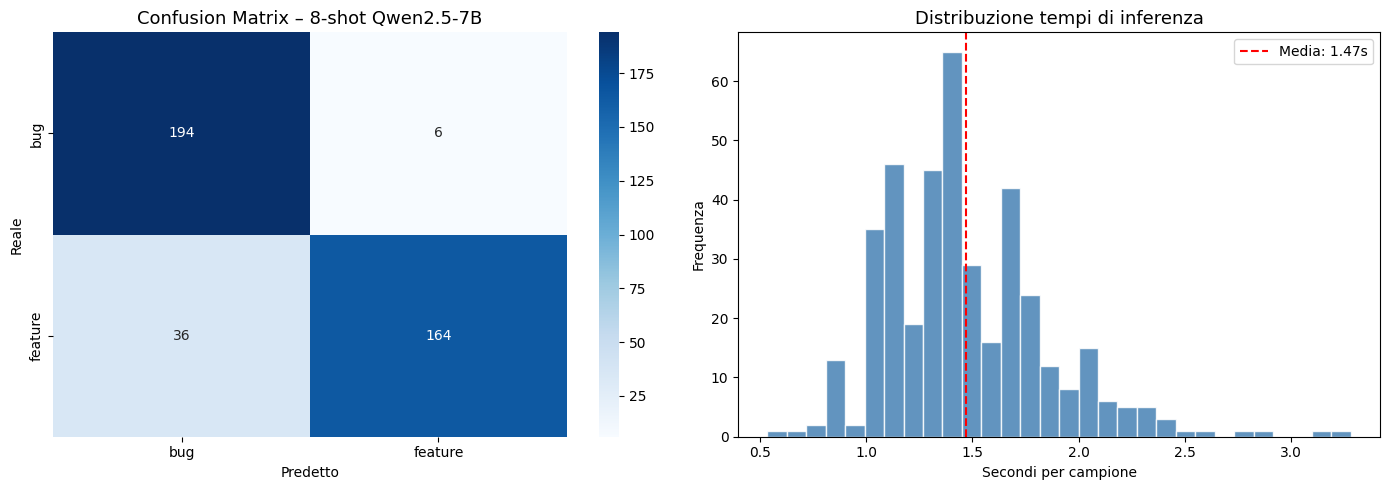

In [ ]:
# Confusion Matrix + Distribuzione tempi di inferenza 
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Confusion matrix
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues',
    xticklabels=['bug', 'feature'],
    yticklabels=['bug', 'feature'],
    ax=axes[0]
)
axes[0].set_title(f'Confusion Matrix – {N_SHOTS}-shot Qwen2.5-7B', fontsize=13)
axes[0].set_xlabel('Predetto')
axes[0].set_ylabel('Reale')

# Distribuzione tempi di inferenza
axes[1].hist(inference_times, bins=30, color='steelblue', edgecolor='white', alpha=0.85)
axes[1].axvline(np.mean(inference_times), color='red', linestyle='--',
                label=f'Media: {np.mean(inference_times):.2f}s')
axes[1].set_title('Distribuzione tempi di inferenza', fontsize=13)
axes[1].set_xlabel('Secondi per campione')
axes[1].set_ylabel('Frequenza')
axes[1].legend()

plt.tight_layout()
plt.savefig(f"{FIGURES_PATH}fewshot_confusion_matrix.png", dpi=150)
plt.show()

## Ablation study: impatto del numero di shot

Valutiamo come cambia la performance al variare del numero di esempi nel prompt (0-shot, 2-shot, 4-shot, 8-shot). Usiamo un sotto-campione di 100 elementi per ridurre i tempi.

Lo 0-shot è incluso come baseline. Con zero esempi il modello si affida esclusivamente alla comprensione semantica delle istruzioni, senza alcun contesto contestuale. Il confronto con 2/4/8-shot quantifica il contributo effettivo degli esempi.

In [ ]:
ablation_n_shots = [0, 2, 4, 8]
ablation_results = {}

#loop esplicito invece di groupby().apply()
groups = []
for label, df_group in df_eval.groupby('label'):
    groups.append(df_group.sample(n=50, random_state=RANDOM_SEED))
df_ablation = pd.concat(groups).sample(frac=1, random_state=RANDOM_SEED).reset_index(drop=True)

print(f"Ablation su {len(df_ablation)} campioni\n")

for n_s in ablation_n_shots:
    print(f"Valutazione {n_s}-shot...")

    shots = [] if n_s == 0 else select_few_shot_examples(df_train, n_s, seed=RANDOM_SEED)

    preds = []
    for _, row in tqdm(df_ablation.iterrows(), total=len(df_ablation), leave=False):
        preds.append(classify_issue(str(row.get('text', '')), shots))

    trues_ab = [t for t, p in zip(df_ablation['label'].tolist(), preds) if p != 'unknown']
    preds_ab = [p for p in preds if p != 'unknown']

    ablation_results[n_s] = {
        'accuracy' : accuracy_score(trues_ab, preds_ab),
        'f1_score' : f1_score(trues_ab, preds_ab, average='macro', zero_division=0),
        'unknown%' : (preds.count('unknown') / len(preds)) * 100
    }
    print(f"  Accuracy={ablation_results[n_s]['accuracy']:.3f}  "
          f"F1={ablation_results[n_s]['f1_score']:.3f}  "
          f"Unknown={ablation_results[n_s]['unknown%']:.1f}%")

print("\nAblation completata.")

Ablation su 100 campioni

Valutazione 0-shot...


  Accuracy=0.820  F1=0.820  Unknown=0.0%
Valutazione 2-shot...


  Accuracy=0.840  F1=0.836  Unknown=0.0%
Valutazione 4-shot...


  Accuracy=0.850  F1=0.847  Unknown=0.0%
Valutazione 8-shot...


  Accuracy=0.910  F1=0.909  Unknown=0.0%

Ablation completata.


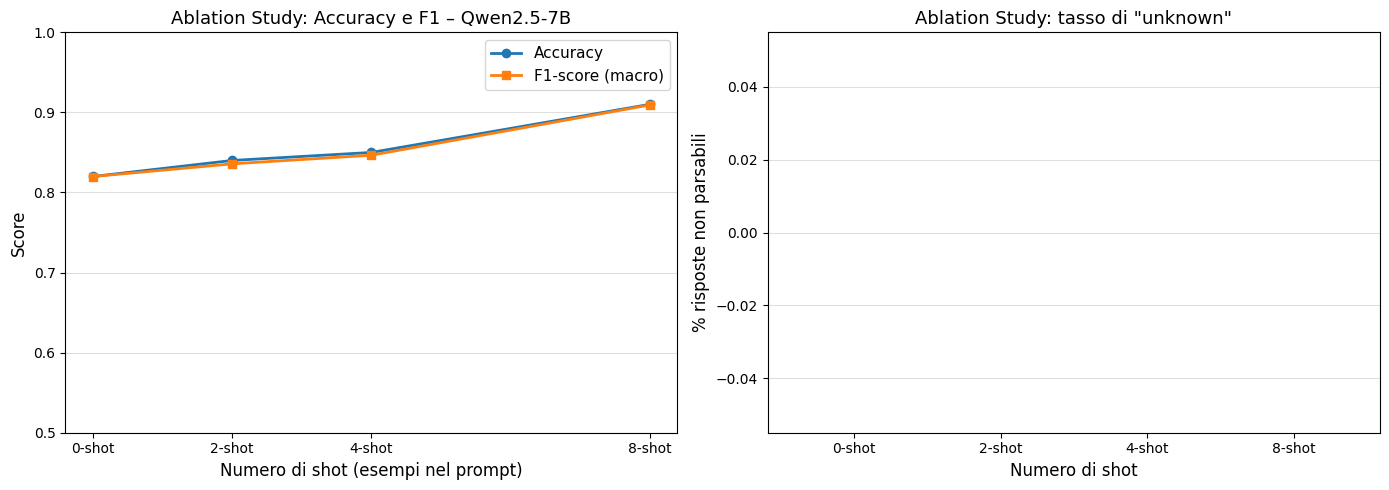

In [20]:
# Plot ablation study
shot_values = list(ablation_results.keys())
acc_values  = [ablation_results[n]['accuracy'] for n in shot_values]
f1_values   = [ablation_results[n]['f1_score'] for n in shot_values]
unk_values  = [ablation_results[n]['unknown%'] for n in shot_values]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy e F1
axes[0].plot(shot_values, acc_values, marker='o', label='Accuracy', linewidth=2)
axes[0].plot(shot_values, f1_values,  marker='s', label='F1-score (macro)', linewidth=2)
axes[0].set_xlabel('Numero di shot (esempi nel prompt)', fontsize=12)
axes[0].set_ylabel('Score', fontsize=12)
axes[0].set_title('Ablation Study: Accuracy e F1 – Qwen2.5-7B', fontsize=13)
axes[0].set_xticks(shot_values)
axes[0].set_xticklabels([f'{n}-shot' for n in shot_values])
axes[0].legend(fontsize=11)
axes[0].set_ylim(0.5, 1.0)
axes[0].grid(axis='y', alpha=0.4)

# % unknown (parsability)
axes[1].bar([f'{n}-shot' for n in shot_values], unk_values,
            color='salmon', edgecolor='white')
axes[1].set_xlabel('Numero di shot', fontsize=12)
axes[1].set_ylabel('% risposte non parsabili', fontsize=12)
axes[1].set_title('Ablation Study: tasso di "unknown"', fontsize=13)
axes[1].grid(axis='y', alpha=0.4)

plt.tight_layout()
plt.savefig(f"{FIGURES_PATH}fewshot_ablation_nshot.png", dpi=150)
plt.show()

## Confronto con gli approcci precedenti

In [ ]:
# Caricamento risultati degli approcci precedenti
previous_results = {
    'TF-IDF (SVM)'             : '../results/tfidf_results.json',
    'Word2Vec (SVM)'           : '../results/word2vec_results.json',
    'GloVe (SVM)'              : '../results/glove_results.json',
    'DistilBERT Embeddings'    : '../results/metrics_distilbert_embeddings.json',
    'BERT Fine-tuned'          : '../results/metrics_bert.json',
}

def extract_best_metrics(data: dict) -> dict:
    """
    Estrae le metriche del miglior classificatore da un JSON di risultati.
    Gestisce sia strutture piatte {clf: metrics} sia annidate {model: {clf: metrics}}.
    """
    # Appiattisce un eventuale livello di nesting extra per accomodare strutture diverse nei JSON
    flat = {}
    for k, v in data.items():
        if isinstance(v, dict):
            # Se i valori interni sono ancora dict, li unisce al livello superiore
            if all(isinstance(vv, dict) for vv in v.values()):
                flat.update(v)
            else:
                flat[k] = v

    # Prende il classificatore con F1 più alto
    best = max(
        flat.items(),
        key=lambda x: x[1].get('f1_score', x[1].get('metrics', {}).get('f1_score', 0))
    )
    metrics = best[1] if 'accuracy' in best[1] else best[1].get('metrics', {})
    return metrics

comparison = []

for name, path in previous_results.items():
    try:
        with open(path) as f:
            data = json.load(f)
        metrics = extract_best_metrics(data)
        comparison.append({
            'Approccio': name,
            'Accuracy' : metrics.get('accuracy',  float('nan')),
            'F1-score' : metrics.get('f1_score',  float('nan')),
        })
    except Exception as e:
        print(f"  ⚠ Non riesco a caricare {path}: {e}")

# Aggiunge risultato few-shot
comparison.append({
    'Approccio': f'Few-shot ({N_SHOTS}-shot) Qwen2.5-7B',
    'Accuracy' : acc,
    'F1-score' : f1,
})

df_comparison = pd.DataFrame(comparison).sort_values('F1-score', ascending=False).reset_index(drop=True)
print(df_comparison.to_string(index=False))

                   Approccio  Accuracy  F1-score
             BERT Fine-tuned  0.899957  0.901255
Few-shot (8-shot) Qwen2.5-7B  0.895000  0.894406
                TF-IDF (SVM)  0.885880  0.885819
       DistilBERT Embeddings  0.880949  0.880839
              Word2Vec (SVM)  0.877019  0.876914
                 GloVe (SVM)  0.831070  0.830897


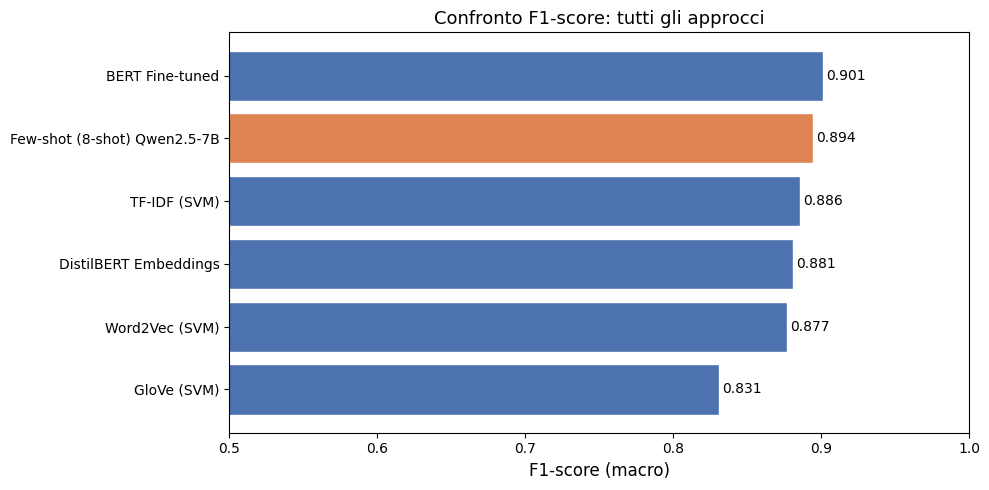

In [26]:
# Plot confronto 
colors = [
    '#DD8452' if 'Few-shot' in str(approccio) else '#4C72B0'
    for approccio in df_comparison['Approccio']
]

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(df_comparison['Approccio'], df_comparison['F1-score'],
               color=colors, edgecolor='white')
ax.set_xlabel('F1-score (macro)', fontsize=12)
ax.set_title('Confronto F1-score: tutti gli approcci', fontsize=13)
ax.set_xlim(0.5, 1.0)
ax.invert_yaxis()

for bar, val in zip(bars, df_comparison['F1-score']):
    ax.text(val + 0.002, bar.get_y() + bar.get_height() / 2,
            f'{val:.3f}', va='center', fontsize=10)

plt.tight_layout()
plt.savefig(f"{FIGURES_PATH}fewshot_comparison.png", dpi=150)
plt.show()

## Salvataggio risultati

In [27]:
results_to_save = {
    f"qwen2.5_7b_{N_SHOTS}shot": {
        "model"           : MODEL_NAME,
        "n_shots"         : N_SHOTS,
        "subset_size"     : len(y_true_filtered),
        "accuracy"        : round(acc,  6),
        "precision"       : round(prec, 6),
        "recall"          : round(rec,  6),
        "f1_score"        : round(f1,   6),
        "ci_95"           : [round(ci_low, 4), round(ci_high, 4)],
        "unknown_pct"     : round(unknown_count / len(y_pred) * 100, 2),
        "avg_time_s"      : round(np.mean(inference_times), 3),
        "confusion_matrix": cm.tolist(),
        "ablation"        : {str(k): v for k, v in ablation_results.items()}
    }
}

import os
os.makedirs(os.path.dirname(RESULTS_PATH), exist_ok=True)
with open(RESULTS_PATH, 'w') as f:
    json.dump(results_to_save, f, indent=4)

print(f"Risultati salvati in: {RESULTS_PATH}")

Risultati salvati in: ../results/fewshot_results.json


## Analisi degli errori

Esaminiamo i casi in cui il modello sbaglia per capire dove il few-shot learning fatica.

Le tipologie di errore più interessanti da analizzare sono:
- **bug → feature**: issue che descrivono un comportamento anomalo ma con linguaggio da feature request (es. *"It would be great if the app didn't crash"*)
- **feature → bug**: issue che chiedono nuove funzionalità ma usano terminologia tecnica che ricorda un bug report (es. *"TypeError when trying to add dark mode"*)

In [29]:
# Raccolta errori
errors = []
for i, (true, pred) in enumerate(zip(y_true, y_pred)):
    if pred != 'unknown' and pred != true:
        row = df_eval.iloc[i]
        errors.append({
            'text'      : str(row.get('text', ''))[:100],
            'true_label': true,
            'pred_label': pred,
        })

df_errors = pd.DataFrame(errors)
print(f"Errori totali: {len(df_errors)} su {len(y_true_filtered)} ({len(df_errors)/len(y_true_filtered)*100:.1f}%)")
print("\nDistribuzione errori per tipo:")
print(df_errors.groupby(['true_label', 'pred_label']).size())

print("\nEsempi di errori (bug classificato come feature):")
for _, row in df_errors[df_errors['true_label'] == 'bug'].head(5).iterrows():
    print(f"  → {row['text']}")

print("\nEsempi di errori (feature classificato come bug):")
for _, row in df_errors[df_errors['true_label'] == 'feature'].head(5).iterrows():
    print(f"  → {row['text']}")

Errori totali: 42 su 400 (10.5%)

Distribuzione errori per tipo:
true_label  pred_label
bug         feature        6
feature     bug           36
dtype: int64

Esempi di errori (bug classificato come feature):
  → click to expect the hover display information to be dynamically updated without refreshing the hover
  → lack of appending html tag attrs in not-found ### Verify canary release

- [X] I verified that the i
  → GLES2 MSAA implementation relies on platform-defines instead of feature-based ones **Godot version:*
  → Warn when invalid "unstable" value in deno.jsonc ```json
{
  "tasks": {
    "start": "deno run in
  → debug: Indicate column of stack frame in editor <!-- ⚠️⚠️ Do Not Delete This! feature_request_templa

Esempi di errori (feature classificato come bug):
  → Cannot download videos from HKET. ### Checklist

- [X] I'm reporting a bug unrelated to a specific s
  → GLM4 tools support GML4 support tools - https://github.com/THUDM/GLM-4/blob/main/finetune_demo/READM
  → SIF

## Discussione e conclusioni

### Interpretazione dei risultati

Il few-shot learning con **Qwen2.5-7B** rappresenta un approccio fondamentalmente diverso dagli altri esplorati in questo progetto:

| Dimensione | Approcci 01-05 | Few-shot LLM |
|---|---|---|
| **Addestramento** | Richiede train set completo | Zero training |
| **Dati etichettati** | Migliaia di esempi | Solo N esempi nel prompt |
| **Infrastruttura** | Scikit-learn / HuggingFace | Modello locale via Ollama |
| **Tempo di setup** | Alto (train + tune) | Basso (prompt design) |
| **Costo per inferenza** | Basso (ms) | Alto (~2s per esempio) |
| **Interpretabilità** | Media | Alta (prompt leggibile) |

### Quando usare il few-shot?

Il few-shot learning è particolarmente utile quando:
- I dati etichettati sono scarsi o costosi da produrre
- Il task cambia frequentemente (basta modificare il prompt)
- Si vuole un sistema rapidamente prototipabile senza pipeline ML
- La latenza non è critica (applicazioni batch o a basso volume)

### Limiti osservati

- Costo computazionale: ~2-4s per inferenza rende il metodo inadatto a scenari real-time su larga scala
- Sensibilità al prompt: piccole variazioni nella formulazione possono cambiare i risultati — il fix dell'ordine interleaved mitiga ma non elimina questo problema
- Rischio di allucinazione: il parsing della risposta è fondamentale per gestire output inattesi (da qui l'importanza di `num_predict` e stop tokens corretti)
- Dipendenza dal contesto: il modello può essere influenzato dall'ordine degli esempi nel prompt — per scenari di produzione si consiglia di fare una media su più permutazioni degli shot